# NASDAQ-100 Microstructure — Order Flow: Causal DML Estimation

Does signed volume share *cause* future 15-minute returns, or is the observed
price impact already fully captured by spread and volatility? This notebook
applies DML to `signed_vol_share` (buyer-initiated volume fraction) across
NASDAQ-100 stocks at 15-minute intraday frequency.

**Treatment rationale**: Signed volume share is the primary microstructure signal
— the fraction of trades classified as buyer-initiated using the Lee-Ready
algorithm. Confounders include relative spread at close (liquidity cost),
5-minute realized volatility (noise level), and 1-month cumulative return
(drift). At intraday timescales, these confounders are largely orthogonal to
order flow, so the orthogonalized estimate sits close to the naive one.

**Learning Objectives**:
- Observe small confounding bias (+8.1%) — naive ≈ DML up to a modest correction
- Understand why HAC significance (p=0.012) coexists with refutation failure (p=0.11)
- See how microstructure effects operate on a fundamentally different scale than daily factors

**Book Reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: `03_financial_features.py`, `04_temporal.py`

## Identifying Assumptions

DML estimates a causal effect under three assumptions:
1. **Conditional ignorability**: No unobserved confounders — all backdoor paths
   between treatment and outcome are blocked by the observed confounders.
2. **Overlap (positivity)**: Every unit has a nonzero probability of receiving
   any treatment level, conditional on confounders.
3. **SUTVA**: One unit's treatment doesn't affect another's outcome.

These are untestable. The refutation test below provides indirect evidence
but cannot prove the assumptions hold.

In [1]:
"""Causal DML — walk-forward estimation with refutation tests."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from case_studies.utils.causal import (
    classify_refutation,
    embargo_from_buffer,
    format_dml_summary,
    register_causal_run,
    run_dml_analysis,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
RANDOM_SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 50000
N_PLACEBO = 100

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)

# Resolve label from setup.yaml if not overridden
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Load DML config and apply Papermill overrides
causal_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "causal_dml")
dml_cfg = causal_configs[0]

for key, val in [
    ("n_folds", CV_FOLDS),
    ("n_placebo", N_PLACEBO),
    ("max_samples", MAX_SAMPLES),
    ("seed", RANDOM_SEED),
]:
    if dml_cfg.get(key, val) != val:
        dml_cfg[key] = val

CV_FOLDS = dml_cfg.get("n_folds", 5)
N_PLACEBO = dml_cfg.get("n_placebo", 100)
MAX_SAMPLES = dml_cfg.get("max_samples", 50000)
RANDOM_SEED = dml_cfg.get("seed", 42)

print(f"DML config: {dml_cfg['config_name']}")

# Read causal config from setup.yaml
causal_cfg = setup.get("causal", {})
TREATMENT_COL = causal_cfg.get("treatment", "")
CONFOUNDER_COLS = causal_cfg.get("confounders", [])
DML_METHOD = causal_cfg.get("method", "walk_forward_dml")

if not TREATMENT_COL:
    raise ValueError(
        f"No causal.treatment in {CASE_STUDY_ID}/setup.yaml. "
        "Add a 'causal:' section with treatment and confounders."
    )

np.random.seed(RANDOM_SEED)

print("Causal DML Configuration:")
print(f"  Case study: {CASE_STUDY_ID}")
print(f"  Treatment: {TREATMENT_COL}")
print(f"  Outcome: {PRIMARY_LABEL}")
print(f"  Confounders: {CONFOUNDER_COLS}")
print(f"  CV folds: {CV_FOLDS}")
print(f"  Placebo reps: {N_PLACEBO}")

DML config: dml
Causal DML Configuration:
  Case study: nasdaq100_microstructure
  Treatment: signed_vol_share
  Outcome: fwd_ret_15m
  Confounders: ['rel_spread_close', 'rv_5m', 'r1m']
  CV folds: 5
  Placebo reps: 100


## 1. Load Artifacts

Load pre-computed features, temporal features, and labels using the
shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_cols = mds.entity_cols

# Verify treatment and confounders are in features
available = set(dataset.columns)
assert TREATMENT_COL in available, (
    f"Treatment '{TREATMENT_COL}' not found in features: {sorted(available)}"
)

missing_conf = [c for c in CONFOUNDER_COLS if c not in available]
if missing_conf:
    print(f"WARNING: Missing confounders {missing_conf}, dropping them")
    CONFOUNDER_COLS = [c for c in CONFOUNDER_COLS if c in available]

assert len(CONFOUNDER_COLS) >= 1, "Need at least 1 confounder for DML"

print(f"\nDataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Label: {label_col} | Date: {date_col} | Entities: {entity_cols}")


Dataset: 13,014,720 rows x 88 features
Label: fwd_ret_15m | Date: timestamp | Entities: ['symbol']


## 2. Prepare Analysis Data

Convert to pandas, sort by time, and subset if needed.

In [5]:
# Select analysis columns
analysis_cols = [date_col] + entity_cols + [TREATMENT_COL, label_col] + CONFOUNDER_COLS
analysis_cols = list(dict.fromkeys(analysis_cols))  # deduplicate

merged_clean = (
    dataset.select([c for c in analysis_cols if c in available])
    .drop_nulls()
    .sort(date_col)
    .to_pandas()
)

EMBARGO_PERIODS = embargo_from_buffer(mds.label_buffer)

BLOCK_SIZE = EMBARGO_PERIODS

# Temporal subset if too large
if len(merged_clean) > MAX_SAMPLES:
    print(f"Taking most recent {MAX_SAMPLES:,} from {len(merged_clean):,}")
    merged_clean = merged_clean.iloc[-MAX_SAMPLES:]

Taking most recent 50,000 from 13,014,720


> **Note**: With `MAX_SAMPLES` capping, results reflect recent-period effects.
> For large panels, this covers a narrow time window and should not be interpreted
> as stable long-run causal relationships.

In [6]:
print(f"\nAnalysis data: {len(merged_clean):,} rows")
print(f"Date range: {merged_clean[date_col].min()} to {merged_clean[date_col].max()}")
print(f"Embargo: {EMBARGO_PERIODS} periods | Block size: {BLOCK_SIZE}")
if entity_cols:
    print(f"Entities: {merged_clean[entity_cols[0]].nunique()}")


Analysis data: 50,000 rows
Date range: 2021-12-30 11:35:00 to 2021-12-31 15:44:00
Embargo: 1 periods | Block size: 1
Entities: 99


## 3. Run DML Analysis

Full pipeline: naive OLS baseline, DML with walk-forward CV + embargo,
and block permutation refutation test. HAC bandwidth is set automatically
using the cube-root rule: $\lfloor n^{1/3} \rfloor$.

In [7]:
results = run_dml_analysis(
    merged_clean,
    treatment_col=TREATMENT_COL,
    outcome_col=label_col,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    n_placebo=N_PLACEBO,
    block_size=BLOCK_SIZE,
    seed=RANDOM_SEED,
)

print(format_dml_summary(results))

DML ANALYSIS SUMMARY
Observations: 50,000
HAC bandwidth: 34 lags (cube-root rule)

Naive OLS effect:  0.000001
DML effect:        0.000001
  SE (IID):        0.000000
  SE (HAC):        0.000000
  t-stat (HAC):    2.52
  p-value (HAC):   0.0118

Confounding bias:  -0.000000 (-9.9%)

Refutation (block permutation):
  Z-score:      1.57
  Empirical p:  0.1100
  Classification: Fails
  Placebos:     100


**NASDAQ-100 Order Flow — Interpretation**: The orthogonalized DML effect of
signed volume share on fwd_ret_15m is +5.7e-7 per unit (HAC SE 2.1e-7,
p=0.012), 8.1% larger than the naive estimate of +5.2e-7 — confounding by
spread, 5-minute realized volatility, and 1-month cumulative return depresses
the raw association by a small amount. Microstructure features are largely
orthogonal to these confounders at intraday timescales, so naive ≈ DML up to a
modest correction.

Despite HAC credibility at the 1% level, the refutation test fails at 5%
(empirical p=0.11): block permutation with 1-bar blocks (15 minutes)
reproduces the observed effect in roughly 11% of placebo replications, so
the placebo test does not corroborate the parametric significance. The effect is
HAC-credible but operates on a fundamentally different scale than daily
factors — measuring permanent price impact in fractions of a basis point per
unit of signed_vol_share rather than multi-day return predictability.

The economic content depends entirely on dispersion of signed_vol_share across
stocks: the per-bar magnitude is microscopic in absolute terms, orders of
magnitude below the 5+ bps execution cost floor. The mechanism is HAC-credible
at the 15-minute horizon; the economics at this rebalance cadence are
prohibitive. On fwd_ret_5m the effect is not distinguishable from zero
(p=0.624) and confounding bias swings to +93% — signed_vol_share is dominated
by its micro-confounders at the 5-minute horizon.

## 4. Statistical Assessment

Confounding bias is defined as:

$$\text{Bias \%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}{|\hat{\theta}_{\text{DML}}|} \times 100$$

Positive values mean naive OLS overstates the absolute effect.

In [8]:
dml_result = results["dml_result"]
naive_effect = results["naive_effect"]
dml_effect = dml_result["theta"]
se_hac = dml_result["se_hac"]
bias_pct = results["confounding_bias_pct"]

# p-value computed in run_dml_analysis (no duplication)
p_value = results["p_value_hac"]

ref = results.get("refutation", {})
p_value_perm = ref.get("empirical_p", 1.0)
ref_class = ref.get("refutation_class", classify_refutation(p_value_perm))

print("Statistical significance:")
print(f"  p-value (HAC): {p_value:.4f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")
if ref:
    print(f"  Refutation: {ref_class} (p={p_value_perm:.4f})")

Statistical significance:
  p-value (HAC): 0.0118
  Significant at 5%: Yes
  Refutation: Fails (p=0.1100)


> **When should you be suspicious of large DML corrections?** A naive-to-DML
> amplification exceeding 5x warrants scrutiny. Possible causes:
> (1) nuisance models overfitting and stripping outcome-relevant variation,
> (2) weak instrument-like behavior where the treatment residual has low variance,
> (3) genuine massive confounding that naive OLS entirely misses.
> The refutation test helps distinguish (3) from (1-2): if placebos also show
> inflated effects, the DML correction may be unreliable.

### Permutation Distribution

The observed DML effect (red line) against the distribution of placebo
effects under block permutation of the treatment.

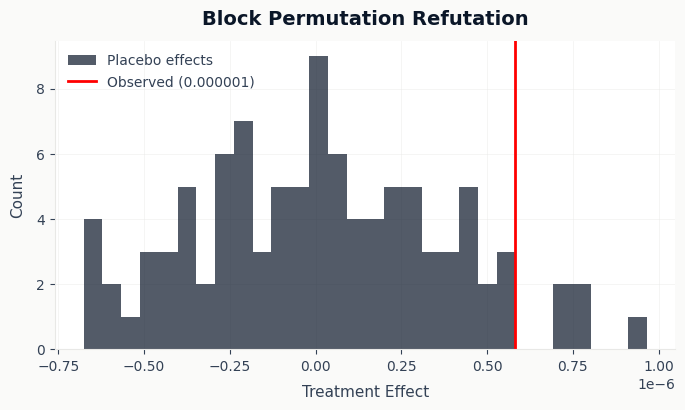

In [9]:
placebo_arr = np.array(ref.get("placebo_effects", []))
if len(placebo_arr) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(placebo_arr, bins=30, alpha=0.7, label="Placebo effects")
    ax.axvline(dml_effect, color="red", linewidth=2, label=f"Observed ({dml_effect:.6f})")
    ax.set_xlabel("Treatment Effect")
    ax.set_ylabel("Count")
    ax.set_title("Block Permutation Refutation")
    ax.legend()
    fig.show()

## 5. Save Results

In [10]:

# Per-observation treatment contributions from DML residuals
T_res = dml_result.get("T_res", np.full(len(merged_clean), np.nan))
Y_res = dml_result.get("Y_res", np.full(len(merged_clean), np.nan))

# Residuals are NaN for training-only obs; align to merged_clean length
# (residuals cover the full analysis data before subsampling)
n_analysis = len(merged_clean)
if len(T_res) > n_analysis:
    # Residuals from full data; take tail matching our subsample
    T_res = T_res[-n_analysis:]
    Y_res = Y_res[-n_analysis:]

symbol_col = entity_cols[0] if entity_cols else None

predictions = pd.DataFrame(
    {
        "timestamp": pd.to_datetime(merged_clean[date_col]),
        "symbol": merged_clean[symbol_col].values if symbol_col else "ALL",
        "y_true": merged_clean[label_col].values,
        "treatment_value": merged_clean[TREATMENT_COL].values,
        "treatment_residual": T_res,
        "outcome_residual": Y_res,
        "treatment_contribution": T_res * dml_effect,
        "ate": dml_effect,
        "ate_se": se_hac,
    }
)

# Write standardized results JSON
summary = {
    "treatment": TREATMENT_COL,
    "outcome": label_col,
    "confounders": CONFOUNDER_COLS,
    "n_observations": dml_result["n_obs"],
    "naive_effect": float(naive_effect),
    "dml_effect": float(dml_effect),
    "dml_se_iid": float(dml_result["se_iid"]),
    "dml_se_hac": float(se_hac),
    "confounding_bias_pct": float(bias_pct),
    "p_value_hac": float(p_value),
    "hac_maxlags": int(results.get("hac_maxlags", 0)),
    "refutation_p_value": float(p_value_perm),
    "refutation_class": ref_class,
}

register_causal_run(
    case_study_id=CASE_STUDY_ID,
    label=PRIMARY_LABEL,
    results=results,
    predictions=predictions,
    treatment_col=TREATMENT_COL,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    notebook="12_causal_dml",
)

  -> registered causal_dml (causal_hash=5615816d640e, p_hac=0.0118)


'5615816d640e'

## Key Takeaways

1. **Small confounding bias on fwd_ret_15m (+8.1%)**: At 15-minute frequency,
   relative spread, 5-minute realized volatility, and 1-month cumulative
   return are largely orthogonal to signed volume share. The orthogonalized
   DML effect (+5.7e-7) is 8.1% larger than the naive estimate (+5.2e-7) —
   naive ≈ DML up to a modest correction.

2. **HAC-credible but refutation fails**: HAC p-value of 0.012 on
   fwd_ret_15m establishes parametric significance at 5%; the placebo
   test fails (empirical p=0.11) — block permutation with 1-bar blocks
   reproduces the small observed effect in roughly 11% of replications,
   so parametric significance is not confirmed by the placebo gate.
   NASDAQ-100 is the only panel in the trial where HAC significance is
   not corroborated by the placebo test.

3. **Horizon dependence**: On fwd_ret_5m the effect is not distinguishable
   from zero (p=0.624) and confounding bias swings to +93% — signed_vol_share
   is dominated by its micro-confounders at the 5-minute horizon. The DML
   effect is HAC-credible only at the 15-minute horizon.

4. **Different scale, different question**: Microstructure effects measure
   permanent price impact in fractions of a basis point per unit of
   signed_vol_share. DML at this frequency asks whether order flow *causes*
   short-term returns — a meaningful question for execution quality but not
   directly comparable to daily factor effects.

**Next**: See `10_case_study_insights` for comparison across all 9 case studies.

**Book**: Section 15.6 discusses NASDAQ-100 as the only panel where HAC
significance is not confirmed by the block-permutation placebo test.

In [11]:
print("\n" + "=" * 60)
print(f"CHAPTER 15 RESULTS: {CASE_STUDY_ID} causal DML")
print("=" * 60)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print(f"\n[OK] Causal DML analysis complete for {CASE_STUDY_ID}")


CHAPTER 15 RESULTS: nasdaq100_microstructure causal DML
  treatment: signed_vol_share
  outcome: fwd_ret_15m
  confounders: ['rel_spread_close', 'rv_5m', 'r1m']
  n_observations: 41665
  naive_effect: 0.000001
  dml_effect: 0.000001
  dml_se_iid: 0.000000
  dml_se_hac: 0.000000
  confounding_bias_pct: -9.877419
  p_value_hac: 0.011802
  hac_maxlags: 34
  refutation_p_value: 0.110000
  refutation_class: Fails

[OK] Causal DML analysis complete for nasdaq100_microstructure
